# Lab 6: Unsupervised Learning with Clustering
**CS2227: Artificial Intelligence and Machine Learning**  
---

## Conceptual Overview

Clustering is an **unsupervised learning** task that groups data points into distinct clusters based on similarity.

### K-Means
Attempts to find cluster centers (centroids) that **minimize the variance** within each cluster. It relies heavily on the assumption of **spherical cluster shapes**.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
Real-world data is often non-linear. DBSCAN identifies **dense regions** of data, making it highly effective for complex, intertwined shapes where K-Means fails.


## Implementation: K-Means vs DBSCAN

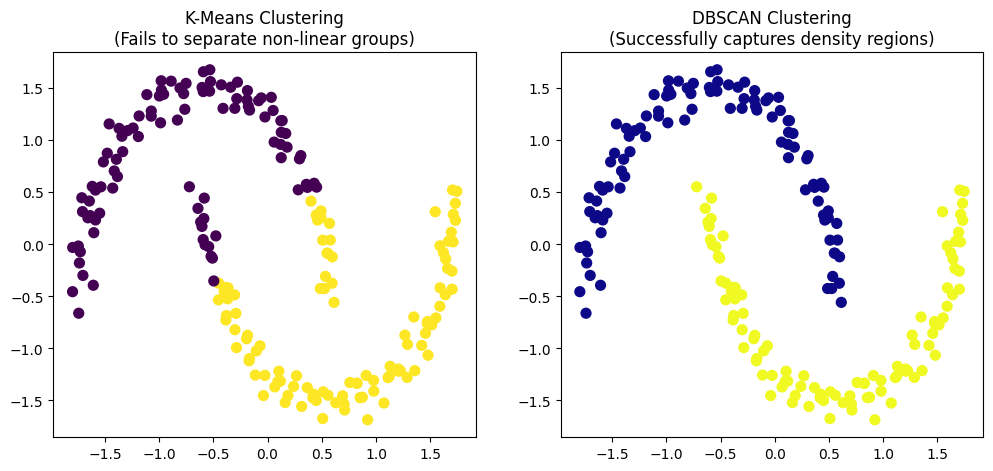

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generate complex, non-linear data (Two overlapping half-circles)
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# Feature scaling is crucial for distance-based algorithms like DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply K-Means (Expectation: It will fail on this non-linear data)
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
kmeans_clusters = kmeans.fit_predict(X_scaled)

# 3. Apply DBSCAN (Expectation: It will successfully find the density regions)
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_scaled)

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot K-Means
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_clusters, cmap='viridis', s=50)
axes[0].set_title('K-Means Clustering\n(Fails to separate non-linear groups)')

# Plot DBSCAN
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_clusters, cmap='plasma', s=50)
axes[1].set_title('DBSCAN Clustering\n(Successfully captures density regions)')

plt.show()


## Key Parameters to Tweak

| Parameter | Algorithm | Description |
|-----------|-----------|-------------|
| `n_clusters` | K-Means | Number of clusters to form. Must be known/guessed beforehand. |
| `eps` | DBSCAN | Maximum distance between two samples for one to be in the neighborhood of the other. Too small = everything is noise. Too large = all points form one cluster. |
| `min_samples` | DBSCAN | Number of samples in a neighborhood for a point to be considered a core point. |


## Lab 6 Exercise

**Task:** Load the `digits` dataset from `sklearn.datasets`. Apply K-Means with `n_clusters=10`.  
Calculate the accuracy of your clustering compared to the true labels.  


In [ ]:
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.stats import mode

# Load the digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Scale the data
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

# Apply K-Means with n_clusters=10
kmeans_digits = KMeans(n_clusters=10, random_state=42, n_init='auto')
cluster_labels = kmeans_digits.fit_predict(X_digits_scaled)

# Map cluster labels to true digit labels using mode
mapped_labels = np.zeros_like(cluster_labels)
for cluster in range(10):
    mask = (cluster_labels == cluster)
    if mask.sum() > 0:
        most_common = mode(y_digits[mask], keepdims=True).mode[0]
        mapped_labels[mask] = most_common

# Calculate accuracy
accuracy = np.mean(mapped_labels == y_digits)
print(f"K-Means Clustering Accuracy on Digits Dataset: {accuracy:.4f} ({accuracy*100:.2f}%)")


K-Means Clustering Accuracy on Digits Dataset: 0.6733 (67.33%)


###Observations

- Accuracy achieved: 67.33%

- Why does K-Means perform reasonably/poorly on this dataset?

  K-Means assume spherical clusters, equal size, no overlap. Digits data = 64D, classes overlap, shapes not spherical. Also K-Means optimize geometry, not class purity — cluster ≠ digit.

- What does the cluster-to-label mapping tell us about unsupervised learning limitations?

  Big limitation: unsupervised learning produce clusters with no semantic meaning. Model find 10 groups but don't know group 3 = digit "7". Need mode trick = manually peek at true labels to assign meaning. That's supervised knowledge sneaking in. Real world: no true labels exist → no way to even do this check. Clusters only tell "these points similar" — not why or what.
